In [17]:
import pandas as pd

# Create data
df = pd.DataFrame({
    "Category": ["A","B","A","C","B","A","C"],
    "Value1": [10,20,30,40,50,60,70],
    "Value2": [100,200,300,400,500,600,700]
})

# Save as CSV
df.to_csv("data.csv", index=False)

print("File created successfully!")

File created successfully!


In [18]:
import os
print(os.listdir())

['.config', 'data.csv', 'sample_data']


Dataset Shape: (7, 3)

First 5 Rows:
  Category  Value1  Value2
0        A      10     100
1        B      20     200
2        A      30     300
3        C      40     400
4        B      50     500

Missing Values:
Category    0
Value1      0
Value2      0
dtype: int64

📊 KPIs
Total Rows: 7
Total Columns: 3
Average of Value1 : 40.0


/tmp/ipykernel_1790/3453003120.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


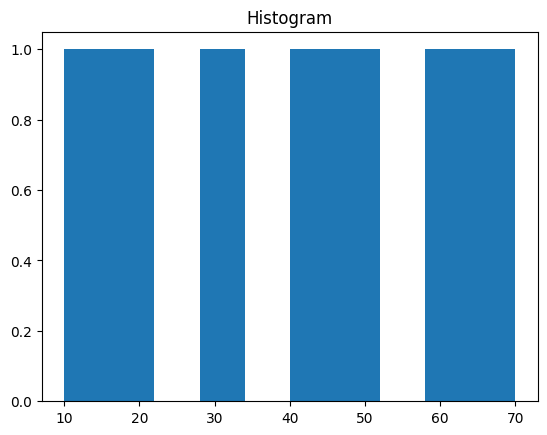

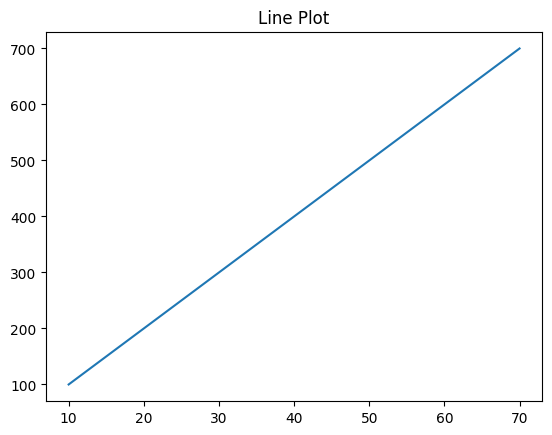

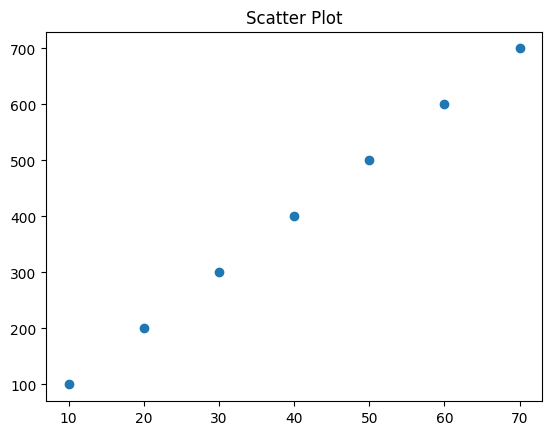

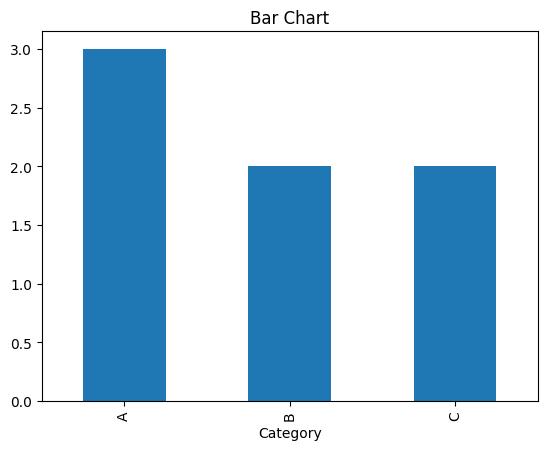

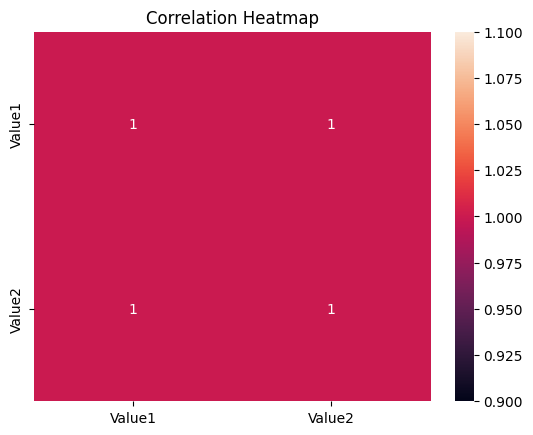

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data.csv")

# DATA OVERVIEW
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# DATA CLEANING
df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)

print("\nMissing Values:")
print(df.isnull().sum())

# KPI METRICS
print("\n📊 KPIs")
print("Total Rows:", len(df))
print("Total Columns:", df.shape[1])

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 0:
    print("Average of", numeric_cols[0], ":", df[numeric_cols[0]].mean())

# VISUALIZATIONS
# 1. Histogram
if len(numeric_cols) > 0:
    plt.figure()
    plt.hist(df[numeric_cols[0]])
    plt.title("Histogram")
    plt.show()

# 2. Line Plot
if len(numeric_cols) > 1:
    plt.figure()
    plt.plot(df[numeric_cols[0]], df[numeric_cols[1]])
    plt.title("Line Plot")
    plt.show()

# 3. Scatter Plot
if len(numeric_cols) > 1:
    plt.figure()
    plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]])
    plt.title("Scatter Plot")
    plt.show()

# 4. Bar Chart (Categorical)
cat_cols = df.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    plt.figure()
    df[cat_cols[0]].value_counts().plot(kind='bar')
    plt.title("Bar Chart")
    plt.show()

# 5. Heatmap (Correlation)
if len(numeric_cols) > 1:
    plt.figure()
    sns.heatmap(df[numeric_cols].corr(), annot=True)
    plt.title("Correlation Heatmap")
    plt.show()